# Display Test Accuracy

In [16]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat

from matplotlib import pyplot as plt
from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

In [17]:
def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test) 


                                        if os.path.exists(event_dir):
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

In [ ]:
availabilities="alphaF50-alpha0.001-8cb alphaF50-alpha0.01-8cb alphaF50-alpha0.1-8cb alphaF50-alpha0.5-8cb alphaF50-alpha0.75-8cb alphaF50-alpha0.9-8cb alphaF50-alpha1.0-8cb".split()

main_folder = 'correlation_experiments_100rounds'
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="mnist_alphaF_var_12346", seeds=["42", "78", "84"],
                          algorithms=["fedavg"], events=["global"],
                        #   lr_list=["1e-1", "5e-2", "1e-2", "5e-3", "1e-3"], alphas=["0.25"], n_clients_list=["7"],
                          lr_list=["5e-2"], alphas=["0.1"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="50", participations=["known"], biased_list=["2"], train_test="train")


results_df = get_exp_stats(config)

results_df

,algorithm,availability,alpha,participation,max_test_accuracy,final_test_accuracy,test_accuracy,seed,lr,event,n_clients,biased
0,fedavg,alphaF50-alpha0.001-8cb,0.1,known,95.929998,95.929998,"[0.12150000035762787, 0.373199999332428, 0.480...",42,5e-2,global,7,2
1,fedavg,alphaF50-alpha0.01-8cb,0.1,known,95.859998,95.859998,"[0.12150000035762787, 0.35830000042915344, 0.4...",42,5e-2,global,7,2
2,fedavg,alphaF50-alpha0.1-8cb,0.1,known,95.959997,95.730001,"[0.12150000035762787, 0.32899999618530273, 0.4...",42,5e-2,global,7,2
3,fedavg,alphaF50-alpha0.5-8cb,0.1,known,90.700001,90.700001,"[0.12150000035762787, 0.499099999666214, 0.555...",42,5e-2,global,7,2
4,fedavg,alphaF50-alpha0.75-8cb,0.1,known,85.949999,83.380002,"[0.12150000035762787, 0.5077999830245972, 0.51...",42,5e-2,global,7,2
5,fedavg,alphaF50-alpha0.9-8cb,0.1,known,87.480003,87.029999,"[0.12150000035762787, 0.5131999850273132, 0.55...",42,5e-2,global,7,2
6,fedavg,alphaF50-alpha1.0-8cb,0.1,known,87.089998,86.489999,"[0.12150000035762787, 0.5142999887466431, 0.55...",42,5e-2,global,7,2
7,fedavg,alphaF50-alpha0.001-8cb,0.1,known,96.149999,96.060002,"[0.1437000036239624, 0.40230000019073486, 0.47...",78,5e-2,global,7,2
8,fedavg,alphaF50-alpha0.01-8cb,0.1,known,96.289998,96.090001,"[0.1437000036239624, 0.4027000069618225, 0.451...",78,5e-2,global,7,2
9,fedavg,alphaF50-alpha0.1-8cb,0.1,known,96.249998,96.249998,"[0.1437000036239624, 0.3889999985694885, 0.444...",78,5e-2,global,7,2


In [19]:
tmp = results_df.groupby(['algorithm', 'availability','lr']).test_accuracy.apply(np.vstack).to_frame().reset_index()

In [20]:
tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
tmp['mean_var_test_acc'] = tmp['var_test_acc'].apply(lambda x : x.mean())
tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))

In [21]:
# tmp_lr = tmp[['algorithm', 'availability', 'lr', 'mean_var_test_acc']]
# display(tmp_lr)

# x_values = [a.replace('gp-','').replace('-10ft', '') for a in tmp_lr.loc[(tmp_lr.lr=="1e-2")&(tmp_lr.algorithm=='fedavg'),'availability']]
# for algo in ['fedavg']:
#     plt.figure()

#     # for lr in ["1e-1", "5e-2", "1e-2", "5e-3"]:
#     for lr in ["1e-2", "5e-2"]:
#         plt.plot(x_values, tmp_lr[(tmp_lr.lr==lr)&(tmp_lr.algorithm==algo)]['mean_var_test_acc'], '-o', label='mean variance '+lr)

#     plt.xticks(rotation=45, ha='right')
#     plt.legend()
#     plt.title(algo+' final min and max test accuracy (mean over seeds) across learning rates.')
#     plt.grid()

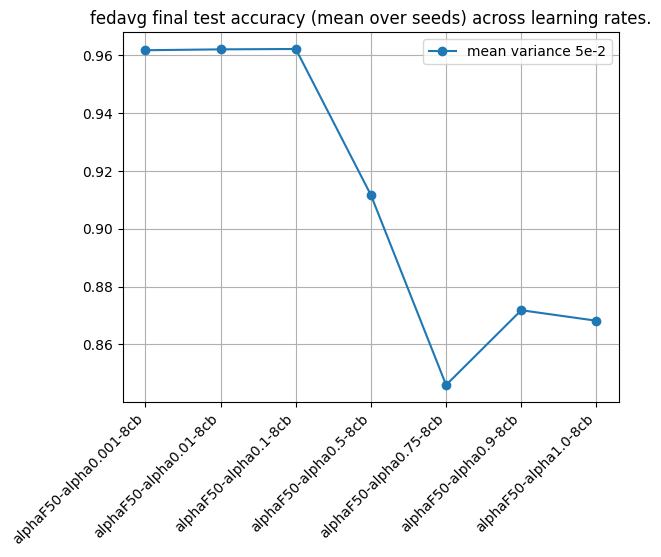

In [22]:
tmp_lr = tmp[['algorithm', 'availability', 'lr', 'final_mean_acc']]

x_values = [a.replace('gp-','').replace('-10ft', '') for a in tmp_lr.loc[(tmp_lr.lr=="5e-2")&(tmp_lr.algorithm=='fedavg'),'availability']]
for algo in ['fedavg']:
    plt.figure()

    # for lr in ["1e-1", "5e-2", "1e-2", "5e-3"]:
    for lr in ["5e-2"]:
        plt.plot(x_values, tmp_lr[(tmp_lr.lr==lr)&(tmp_lr.algorithm==algo)]['final_mean_acc'], '-o', label='mean variance '+lr)

    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.title(algo+' final test accuracy (mean over seeds) across learning rates.')
    plt.grid()

In [23]:
res_old = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()]

In [24]:
max_res = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmax()][['algorithm','availability','final_mean_acc']].rename(columns={'final_mean_acc': 'max_final_mean_acc'})
min_res = tmp.loc[tmp.groupby(['algorithm', 'availability'])['final_mean_acc'].idxmin()][['algorithm','availability','final_mean_acc']].rename(columns={'final_mean_acc': 'min_final_mean_acc'})

In [25]:
res_ = pd.merge(max_res, min_res, on=['algorithm', 'availability'], how='outer')

In [26]:
res_

,algorithm,availability,max_final_mean_acc,min_final_mean_acc
0,fedavg,alphaF50-alpha0.001-8cb,0.961800,0.961800
1,fedavg,alphaF50-alpha0.01-8cb,0.962100,0.962100
2,fedavg,alphaF50-alpha0.1-8cb,0.962233,0.962233
3,fedavg,alphaF50-alpha0.5-8cb,0.911667,0.911667
4,fedavg,alphaF50-alpha0.75-8cb,0.845967,0.845967
5,fedavg,alphaF50-alpha0.9-8cb,0.871833,0.871833
6,fedavg,alphaF50-alpha1.0-8cb,0.868200,0.868200


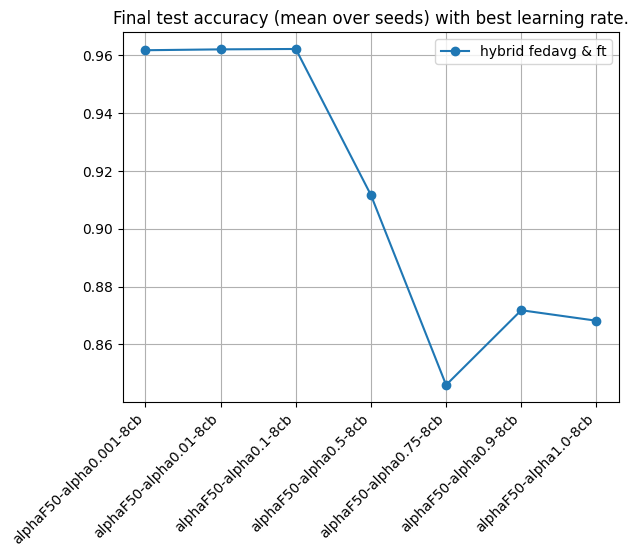

In [27]:
x_values = [a.replace('gp-','').replace('-10ft', '') for a in res_[res_.algorithm=='fedavg']['availability']]

plt.figure()
plt.plot(x_values, res_[res_.algorithm=='fedavg']['max_final_mean_acc'], '-o', label='hybrid fedavg & ft')
# plt.plot(x_values, res_[res_.algorithm=='fedvarp']['max_final_mean_acc'], '-o', label='hybrid fedvarp & ft')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title('Final test accuracy (mean over seeds) with best learning rate.')
plt.grid()

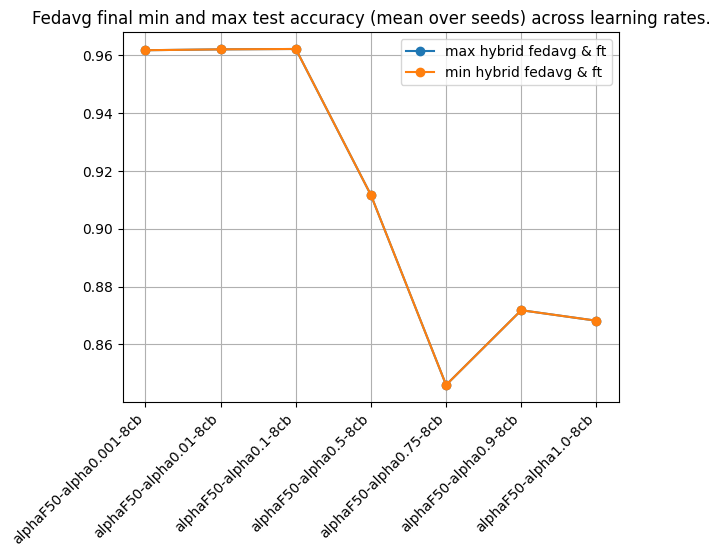

In [28]:
plt.figure()
plt.plot(x_values, res_[res_.algorithm=='fedavg']['max_final_mean_acc'], '-o', label='max hybrid fedavg & ft')
plt.plot(x_values, res_[res_.algorithm=='fedavg']['min_final_mean_acc'], '-o', label='min hybrid fedavg & ft')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title('Fedavg final min and max test accuracy (mean over seeds) across learning rates.')
plt.grid()

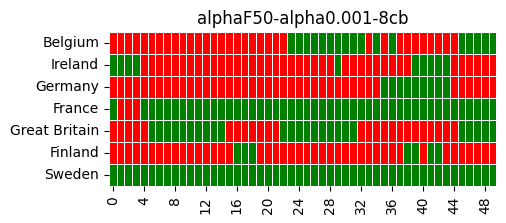

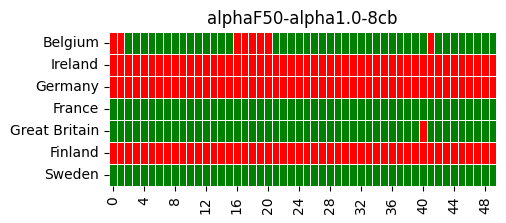

In [29]:
av_mat_list = [
"alphaF50-alpha0.001-8cb",
"alphaF50-alpha1.0-8cb"
]
folder='alphaF_eval/av_mat'
for av_mat_name in av_mat_list:
    plot_av_mat(av_mat_name, folder)